<font size=6>**Advanced RAG for Health Queres**</font>


This project is a personal exploration into building a multimodal AI system focused on human nutrition and health. The goal is to create an intelligent assistant that can answer questions about essential vitamins and minerals using both textual and visual information.

To support this system, the notebook integrates a comprehensive 350-page reference document outlining human vitamin and mineral requirements, along with curated images of common dietary sources for various nutrients. By combining structured nutritional guidelines with relevant visual data, the model is designed to provide more informative, context-aware responses.

Instead of relying solely on traditional consultation formats, this project demonstrates how AI can serve as an accessible educational tool. Users can ask questions about nutrition and receive detailed explanations supported by relevant images, showcasing how multimodal retrieval and generation techniques can enhance understanding and engagement.

**Solution Approach**

The core of the solution involves the creation of an AI-based Advanced Retrieval-Augmented Generation (RAG) System that encompasses the following key components:

1. **Development of a Text and Image-Based Knowledge Base:** This will compile comprehensive information about vitamins and nutrients, supplemented with relevant images to enrich user understanding.
2. **Implementation of Reranking Methodology:** This process will refine the AI system’s ability to recommend the most relevant responses to user queries, thereby enhancing accuracy and user satisfaction.
3. **Query Expansion Techniques:** These will improve the AI’s comprehension of user queries, making it more efficient in providing precise information tailored to individual needs.

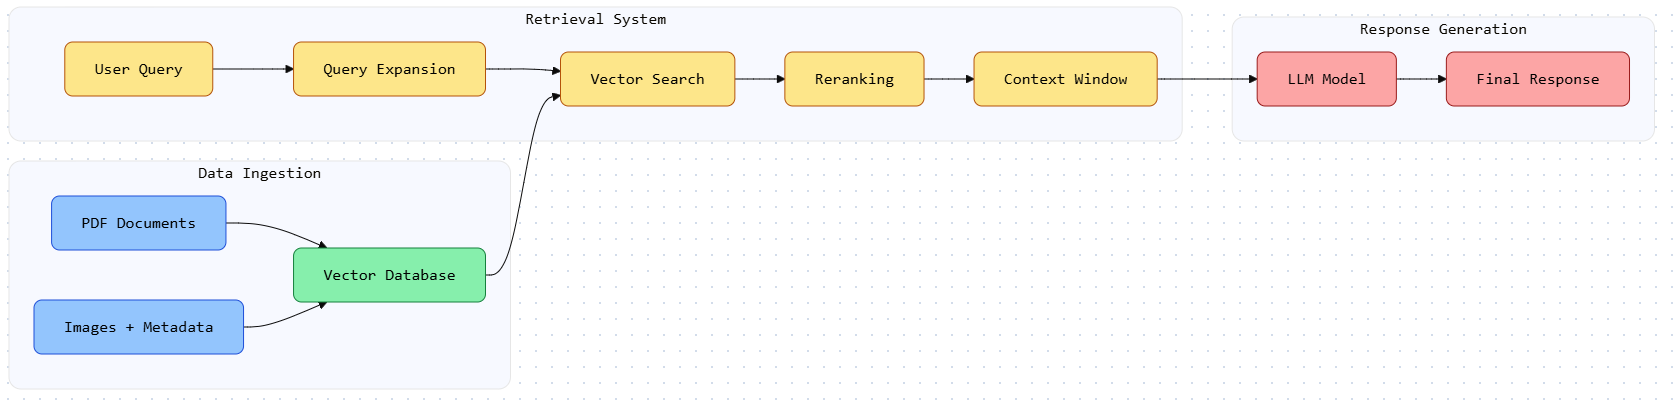

## **Setup**

In [4]:
%pip install langchain_openai==0.3.10
%pip install langchain==0.3.21
%pip install langchain-community==0.3.20
%pip install pypdf==5.4.0

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Run this cell => Restart the session => Start executing the below cells. No need to execute this cell again.

%pip install -q langchain==0.3.21 \
                huggingface_hub==0.29.3 \
                openai==1.68.2 \
                chromadb==0.6.3 \
                langchain-community==0.3.20 \
                langchain_openai==0.3.10 \
                lark==1.2.2\
                rank_bm25==0.2.2\
                numpy==2.2.4 \
                scipy==1.15.2 \
                scikit-learn==1.6.1 \
                transformers==4.50.0 \
                pypdf==5.4.0 \
                markdown-pdf==1.7 \
                sentence_transformers==4.0.0 \
                torch==2.6.0+cu124


%pip install --upgrade chromadb
%pip install pillow
%pip install open-clip-torch
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torch==2.6.0+cu124 (from versions: 2.0.0, 2.0.1, 2.1.0, 2.1.1, 2.1.2, 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==2.6.0+cu124


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**IMPORTANT** The config_template is a place holder. If you are going to implement this notebook, load your API key by replacing "config_template.json" with "config.json. Also, make sure your working directory has a json file to reference in the following format:

{  
  "API_KEY": "YOUR_API_KEY_HERE",  
  "OPENAI_API_BASE": "https://api.openai.com/v1"  
}

I used OpenAI but any model is applicable as long as you make the necessary edits to the below cell.

In [ ]:

import json
import os

# Load the JSON file and extract values
file_name = 'config_template.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url

In [7]:
# Defining the Embedding Model - Using `text-embedding-ada-002` Model
%pip install langchain_openai --quiet

from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Defining the LLM Model - Using `gpt-4o-mini` Model
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## **Step 1 : Loading the PDF and storing it in the vectorDB**


In [9]:
from langchain.document_loaders import PyPDFLoader

# Reading the NOFO Document
pdf_file = "Vitamin_and_minerals.pdf"
pdf_loader = PyPDFLoader(pdf_file);
text_data = pdf_loader.load()

In [10]:
from langchain.vectorstores import Chroma


text_vectorstore = Chroma(
    collection_name="vitamin_and_minerals",
    embedding_function=embeddings)

text_vectorstore.add_documents(documents=text_data)

C:\Users\18304\AppData\Local\Temp\ipykernel_24328\2827020031.py:4: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  text_vectorstore = Chroma(


['f15d8a1a-4b90-458d-8e4b-648d078c8ff4',
 'd7949e03-1653-4b89-a15a-dcd261429408',
 '9c7c3d54-af27-4c91-92c3-ed3c9299d45a',
 '1fd440b0-637d-43b9-a050-13d405577e0d',
 'ee38cdbc-a566-4cf8-b93d-89bcd11bf9f9',
 'de7885b6-adc0-41c7-beb2-e4c7800fdef6',
 'c93c6349-95d3-43c9-8165-72dc60e18072',
 '4844a13b-b5d7-42a6-a30b-fa68d7228dba',
 '3e38e64b-ff3b-4ea2-a169-f02132844a92',
 '430c1f04-6a25-4496-b0d6-d85a8b6352d1',
 '80cb7bbd-e7f2-41c1-bb4d-aee6ac77786f',
 'cb91dce3-8781-4e86-85c3-213c925c7d51',
 'e56476eb-1ad3-4c36-9fd8-dc300dfb61d4',
 '50e7d384-6415-44cd-a0cc-edf51981393a',
 '6744b9f6-95c5-4a68-9ba0-52eec95ec72e',
 '3b1737a9-18ba-4523-b2f0-525bcd3553be',
 '356548d2-fc60-49b2-b060-b50d2cd61c97',
 '8593ec16-f929-4a18-8c34-6ad598769663',
 '6c531f53-1ced-4e75-8123-d33f4179a941',
 '577cb2ea-0b59-4343-a1fb-58bcb54e0574',
 '0fa48efc-b7f8-4957-9d25-ab12933e27d2',
 'de0cbe2f-e509-4abe-b6bc-ca2b11c127da',
 '636e2189-555d-44aa-997c-1eb4b1d5ecff',
 '236655f6-75cb-48f5-bc4e-20afa99083c5',
 'd8ff405f-3e43-

In [11]:
vanilla_retriever = text_vectorstore.as_retriever(search_kwargs={"k": 10}) 
# Initializing the retriever with k=10 to retrieve top 10 relevant documents based on cosine similarity.

## **Step 2 : Loading the Images along with metadata and storing them in the vectorDB**

In [12]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from matplotlib import pyplot as plt
import os

In [13]:
%pip install ipywidgets


Note: you may need to restart the kernel to use updated packages.


In [14]:
# Create database file at folder "my_vectordb" or load into client if exists
chroma_client = chromadb.PersistentClient(path="my_vectordb")

# Instantiate image loader helper
image_loader = ImageLoader()

# Instantiate multimodal embedding function
image_embedding_function = OpenCLIPEmbeddingFunction()

# Create the collection, aka vector database. Or, if database already exist, then use it. Specify the model that we want to use to do the embedding
multimodal_db = chroma_client.get_or_create_collection(name="multimodal_db", embedding_function=image_embedding_function, data_loader=image_loader)

In [ ]:
 # Check the number of documents in the collection. 
multimodal_db.count()

11

In [17]:
from PIL import Image
import numpy as np

image_dir = "sources"
image_paths = [os.path.join(image_dir, file) 
               for file in os.listdir(image_dir)]
image_paths # List of image paths in the "sources" directory


['sources\\VitaminA-1.png',
 'sources\\VitaminA-2.png',
 'sources\\VitaminA-3.png',
 'sources\\VitaminA-4.png',
 'sources\\VitaminA-5.png',
 'sources\\VitaminC-1.png',
 'sources\\VitaminC-2.png',
 'sources\\VitaminC-3.png',
 'sources\\VitaminD-1.png',
 'sources\\VitaminD-2.png',
 'sources\\VitaminD-3.png']

In [18]:
# Defining Metadata
Metadata = []
for file in os.listdir("/content/MLS14 - Adv RAG/sources"):
  Metadata.append({'Vitamin':file.split("-")[0][-1],
                   'info': f'The images shows the sources of Vitamin {file.split("-")[0][-1]}'})

Metadata

[{'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'}]

In [19]:
# Use .add() to add a new record or .update() to update existing record
multimodal_db.add(
    ids=[str(x) for x in range(len(os.listdir("/content/MLS14 - Adv RAG/sources")))],
    uris = image_paths,
    metadatas=Metadata
)

In [20]:
multimodal_db.count()

11

In [21]:
# Simple function to print the results of a query.
# The 'results' is a dict {ids, distances, data, ...}
# Each item in the dict is a 2d list.
def print_query_results(query_list: list, query_results: dict)->None:
    result_count = len(query_results['ids'][0])

    for i in range(len(query_list)):
        for j in range(result_count):
            id       = query_results["ids"][i][j]
            distance = query_results['distances'][i][j]
            data     = query_results['data'][i][j]
            document = query_results['documents'][i][j]
            metadata = query_results['metadatas'][i][j]
            uri      = query_results['uris'][i][j]

            print(f'id: {id}, distance: {distance}, metadata: {metadata}, document: {document}')

            # Display image, the physical file must exist at URI.
            # (ImageLoader loads the image from file)
            print(f'data: {uri}')
            plt.imshow(data)
            plt.axis("off")
            plt.show()

In [22]:
def get_image(query_texts):
# Query vector db
    query_results = multimodal_db.query(
        query_texts = query_texts,
        n_results=2,
        include=['documents', 'distances', 'metadatas', 'data', 'uris'],
    )

    print_query_results(query_texts, query_results)

id: 5, distance: 0.7099937200546265, metadata: {'info': 'The images shows the sources of Vitamin C', 'Vitamin': 'C'}, document: None
data: sources\VitaminC-1.png


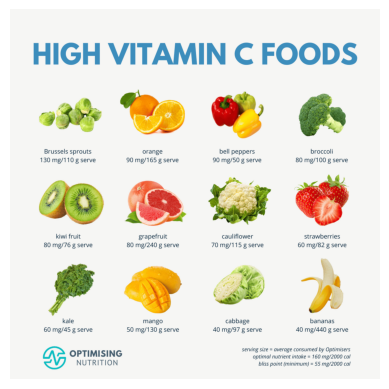

id: 6, distance: 0.7135546207427979, metadata: {'info': 'The images shows the sources of Vitamin C', 'Vitamin': 'C'}, document: None
data: sources\VitaminC-2.png


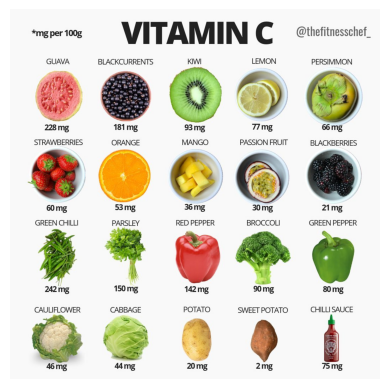

In [23]:
get_image(['Citrus fruits have which common vitamins'])

Reranking

In [24]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
crossencoder = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")

In [25]:
from langchain.retrievers.document_compressors import CrossEncoderReranker
reranker = CrossEncoderReranker(model=crossencoder, top_n=5)

In [26]:
from langchain.retrievers import ContextualCompressionRetriever
reranker_retriever = ContextualCompressionRetriever(
    base_compressor=reranker, base_retriever=vanilla_retriever
)

User Query Expansion

In [27]:
# Query Expansion for User_query

def query_expansion(user_query):
    query_enhancement = f"""
    You are an expert in information retrieval systems, particularly skilled in enhancing queries for document search efficiency.
    Perform query expansion on the received question by considering alternative phrasings or synonyms commonly used in document retrieval contexts.
    If there are multiple ways to phrase the user's question or common synonyms for key terms, provide several reworded versions.

    If there are acronyms or words you are not familiar with, do not try to rephrase them.

    Return at least 3 versions of the question as a list.
    Generate only a list of questions. Do not mention anything before or after the list.

    Question:
    {user_query}
    """


    new_question = llm.invoke(query_enhancement)
    return (new_question.content)

## **Step 3 : Retriever which can allow queres to fetch the data from (PDF + Images)**

In [28]:
user_query = "What is the importance of eating a diverse diet?"

In [29]:
# Query Expansion
multipule_queries = query_expansion(user_query)
print(multipule_queries)

1. Why is it essential to consume a varied diet?
2. What are the benefits of having a diverse range of foods in one's diet?
3. How significant is a balanced and varied diet for health?


In [30]:
# Calling the vanilla retriever
vanilla_responses = vanilla_retriever.get_relevant_documents(multipule_queries)

# We can see the results are not sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in vanilla_responses]
crossencoder.score(context_query_pairs_for_scoring)

C:\Users\18304\AppData\Local\Temp\ipykernel_24328\734080928.py:2: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  vanilla_responses = vanilla_retriever.get_relevant_documents(multipule_queries)


array([-3.7659628, -4.8005714, -3.5776107, -4.0566063, -4.7161713,
       -2.710515 , -7.6508374, -6.791345 , -6.3278065, -5.158636 ],
      dtype=float32)

In the above cell, we can observe that we fetched 10 chunks and they are not sorted. Now, we will be following the re-ranking approach to fetch the 5 most relevant chunks from these 10.

In [31]:
# Calling the reranking retriever
reranked_responses = reranker_retriever.get_relevant_documents(multipule_queries)

In [32]:
# We can see the results are sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in reranked_responses]
crossencoder.score(context_query_pairs_for_scoring)

array([-2.710515 , -3.5776107, -3.7659628, -4.0566063, -4.7161727],
      dtype=float32)

In [33]:
prompt = f"""
You are an expert AI assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.

### Context:
{reranked_responses}

### Question:
{multipule_queries}
"""

In [34]:
llm_response = llm.invoke(prompt)

Answer: 
 1. **Why is it essential to consume a varied diet?**
   Consuming a varied diet is essential because it helps improve the intake of critical nutrients that may be lacking in staple diets, particularly those based on cereals and tubers. A diverse diet ensures that individuals receive a wide range of vitamins and minerals necessary for overall health, as certain nutrients can be difficult to obtain from a limited selection of foods. Additionally, dietary diversity can help prevent nutrient deficiencies and promote better health outcomes.

2. **What are the benefits of having a diverse range of foods in one's diet?**
   The benefits of having a diverse range of foods in one's diet include:
   - Improved intake of essential micronutrients, such as vitamins A, C, iron, and zinc, which are crucial for various bodily functions.
   - Enhanced protection against chronic noncommunicable diseases, as a varied diet is associated with better health outcomes.
   - Increased dietary satisfa

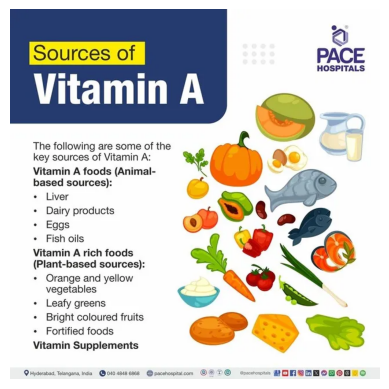

id: 9, distance: 0.716222882270813, metadata: {'info': 'The images shows the sources of Vitamin D', 'Vitamin': 'D'}, document: None
data: sources\VitaminD-2.png


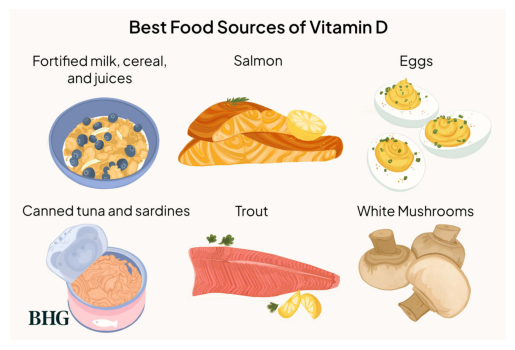

In [35]:
print("Answer: \n", llm_response.content)
print("="*50)
print("Relevant Images: \n")
get_image([llm_response.content])

UI can be enhanced with Gradio

In [ ]:
#!pip install gradio

In [ ]:
import gradio as gr # Importing Gradio for building the user interface

def predict(user_query):

    # Query Expansion
    multipule_queries = query_expansion(user_query)

    # Reranking
    reranked_responses = reranker_retriever.get_relevant_documents(multipule_queries)

    prompt = f"""
    You are an expert AI assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer the question.

    ### Context:
    {reranked_responses}

    ### Question:
    {multipule_queries}
    """

    # Fetching Text
    llm_response = llm.invoke(prompt)

    # Fetching Images
    rel_img = multimodal_db.query(
        query_texts = llm_response.content,
        n_results=2,
        include=['uris'],
    )

    return llm_response.content, rel_img['uris'][0] # Return both text and image paths


iface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="Enter your query"),
    outputs=[gr.Markdown(label= "Answer"), gr.Gallery(label="Relevant Images")],  # Using Gallery for images
    title="Nutritionist AI Assistant",
    description="Ask questions about nutrition and health"
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://7165209985b7409f3a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
